In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
print(df.shape)

(200, 5)


In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


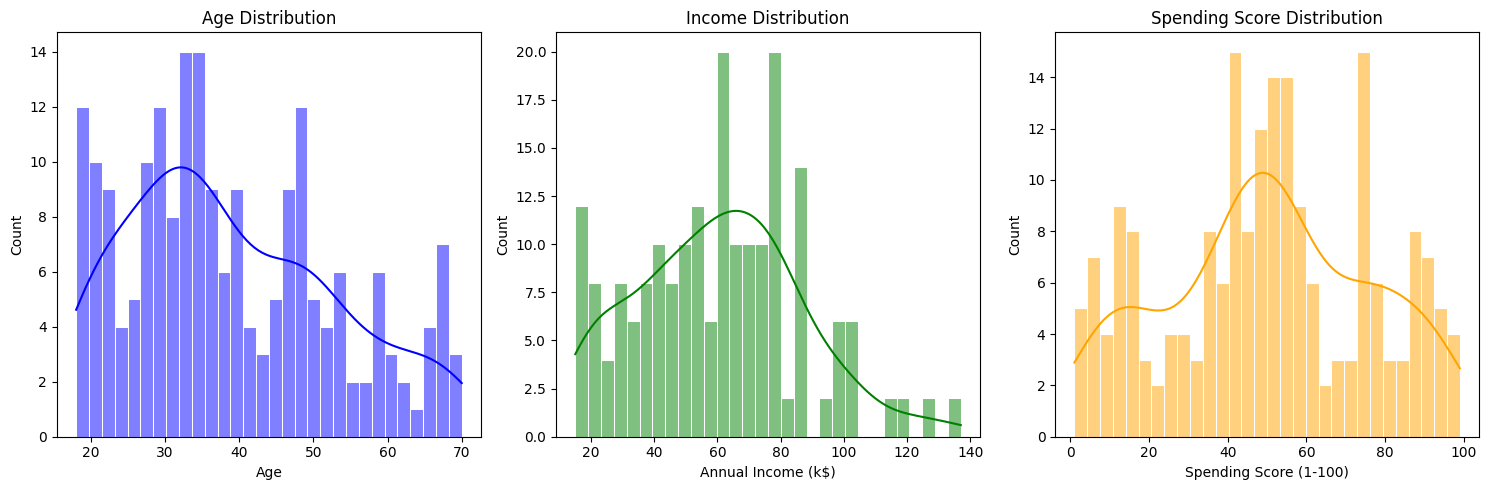

In [7]:
# Distribution plots (numerical)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

sns.histplot(df["Age"], bins=30, color='blue', edgecolor='white', kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], bins=30, color='green', edgecolor='white', kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

sns.histplot(df["Spending Score (1-100)"], bins=30, color='orange', edgecolor='white', kde=True, ax=axes[2])
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()

C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\158440332.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="pastel")


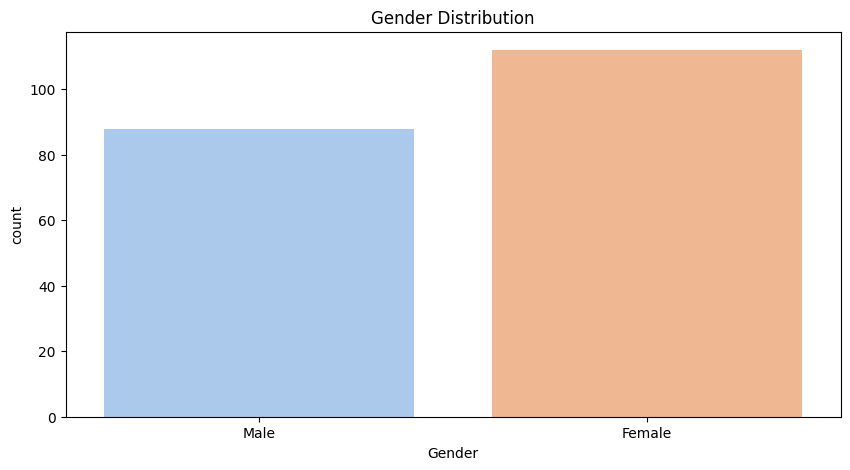

In [8]:
# Distribution plots (categorical)
plt.figure(figsize=(10, 5))
sns.countplot(x="Gender", data=df, palette="pastel")
plt.title("Gender Distribution")
plt.show()

In [9]:
df["Encoded_Gender"] = df["Gender"].map({'Male': 0, 'Female': 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Encoded_Gender
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [10]:
dropping = df.drop(columns=["CustomerID", "Gender"], inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Encoded_Gender
0,19,15,39,0
1,21,15,81,0
2,20,16,6,1
3,23,16,77,1
4,31,17,40,1


In [13]:
from sklearn.preprocessing import StandardScaler

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Shape of scaled features:", X_scaled.shape)

Shape of scaled features: (200, 3)


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
#Run KMeans for multiple K values
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "K": list(K),
    "Inertia": inertia,
    "Silhouette Score": sil_scores
})
print(results)

    K     Inertia  Silhouette Score
0   2  389.386189          0.335472
1   3  295.212246          0.357793
2   4  205.225147          0.403958
3   5  168.247580          0.416643
4   6  133.868421          0.428417
5   7  117.011555          0.417232
6   8  103.873292          0.408207
7   9   93.092891          0.417693
8  10   82.385154          0.406554


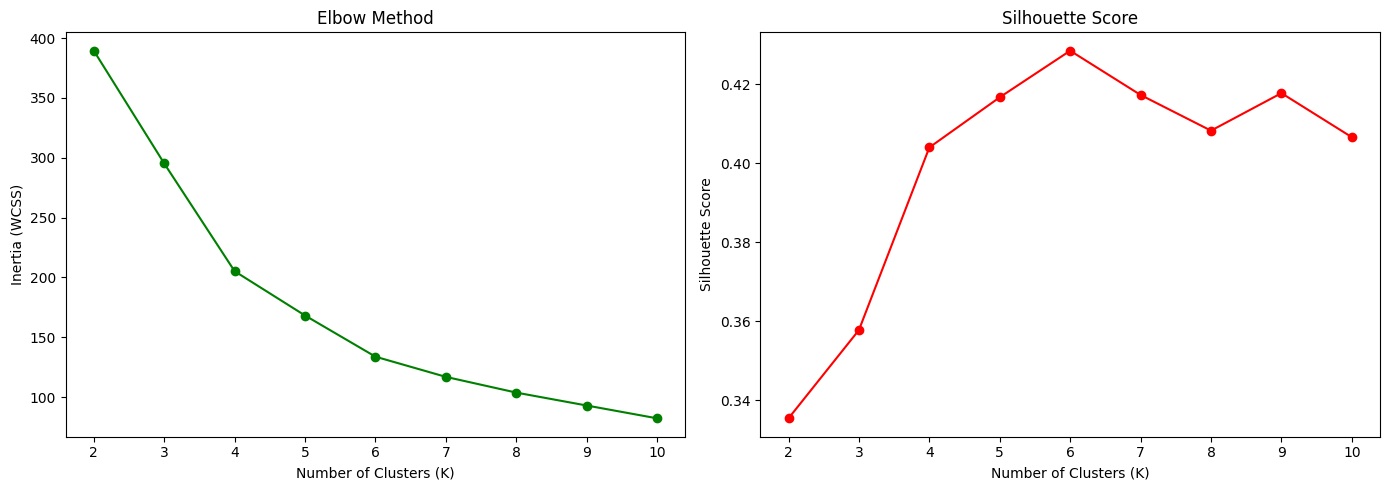

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method
ax[0].plot(K, inertia, marker='o', color='green')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia (WCSS)")

# Silhouette Score
ax[1].plot(K, sil_scores, marker='o', color='red')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [19]:
best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

best_score = results["Silhouette Score"].max()

print(f"Best K: {best_k}")
print(f"Highest Silhouette Score: {best_score:.4f}")


Best K: 6
Highest Silhouette Score: 0.4284


In [23]:
# Train Final K-Means Model
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(X_scaled)

clusters = final_kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

In [24]:
cluster_counts = df["Cluster"].value_counts().sort_index()
print("Customers in Each Cluster:")
print(cluster_counts)

Customers in Each Cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


In [29]:
cluster_summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

cluster_summary["Customer Count"] = cluster_counts

# Reorder columns
cluster_summary = cluster_summary[
    ["Customer Count", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
]

print(cluster_summary)

         Customer Count    Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0                    45  56.33               54.27                   49.07
1                    39  26.79               57.10                   48.13
2                    33  41.94               88.94                   16.97
3                    39  32.69               86.54                   82.13
4                    23  25.00               25.26                   77.61
5                    21  45.52               26.29                   19.38


In [32]:
segment_names = {
    0: "Older Average Spenders",
    1: "Young Average Spenders",
    2: "High Income Low Spenders",
    3: "High Income High Spenders",
    4: "Young High Spenders",
    5: "Low Income Low Spenders"
}

df["Segment"] = df["Cluster"].map(segment_names)
print(df[["Cluster", "Segment"]].value_counts())

Cluster  Segment                  
0        Older Average Spenders       45
1        Young Average Spenders       39
3        High Income High Spenders    39
2        High Income Low Spenders     33
4        Young High Spenders          23
5        Low Income Low Spenders      21
Name: count, dtype: int64


In [36]:
for cluster in cluster_summary.index:

    print("="*60)
    print(f"Cluster {cluster} : {segment_names[cluster]}")
    print(f"Customer Count : {cluster_summary.loc[cluster,'Customer Count']}")
    print(f"Average Age : {cluster_summary.loc[cluster,'Age']:.2f}")
    print(f"Average Income : {cluster_summary.loc[cluster,'Annual Income (k$)']:.2f}")
    print(f"Average Spending : {cluster_summary.loc[cluster,'Spending Score (1-100)']:.2f}")

    if cluster == 3:
        print("Marketing Action : Offer VIP memberships, premium products, and exclusive rewards.")

    elif cluster == 2:
        print("Marketing Action : Encourage purchases using discounts and loyalty rewards.")

    elif cluster == 4:
        print("Marketing Action : Promote trendy products through social media and student discounts.")

    elif cluster == 5:
        print("Marketing Action : Focus on affordable products and seasonal discounts.")

    elif cluster == 1:
        print("Marketing Action : Maintain engagement with personalized offers and loyalty points.")

    elif cluster == 0:
        print("Marketing Action : Promote products suitable for mature customers and repeat purchase offers.")

    print()

Cluster 0 : Older Average Spenders
Customer Count : 45
Average Age : 56.33
Average Income : 54.27
Average Spending : 49.07
Marketing Action : Promote products suitable for mature customers and repeat purchase offers.

Cluster 1 : Young Average Spenders
Customer Count : 39
Average Age : 26.79
Average Income : 57.10
Average Spending : 48.13
Marketing Action : Maintain engagement with personalized offers and loyalty points.

Cluster 2 : High Income Low Spenders
Customer Count : 33
Average Age : 41.94
Average Income : 88.94
Average Spending : 16.97
Marketing Action : Encourage purchases using discounts and loyalty rewards.

Cluster 3 : High Income High Spenders
Customer Count : 39
Average Age : 32.69
Average Income : 86.54
Average Spending : 82.13
Marketing Action : Offer VIP memberships, premium products, and exclusive rewards.

Cluster 4 : Young High Spenders
Customer Count : 23
Average Age : 25.00
Average Income : 25.26
Average Spending : 77.61
Marketing Action : Promote trendy products

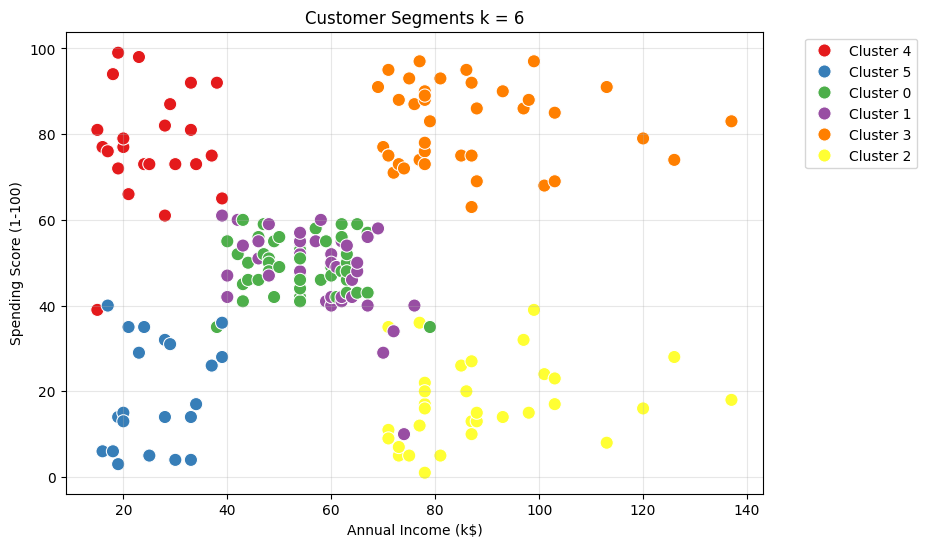

In [63]:
df["Cluster_Label"] = "Cluster " + df["Cluster"].astype(str)
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster_Label",
    palette="Set1",
    s=90
)

plt.title("Customer Segments k = 6")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.grid(alpha=0.3)

plt.show()

C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\2600483478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Age", ax=axes[0], palette="Set2")
C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\2600483478.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", ax=axes[1], palette="Set2")
C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\2600483478.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", ax=axes[2], palette="Set2

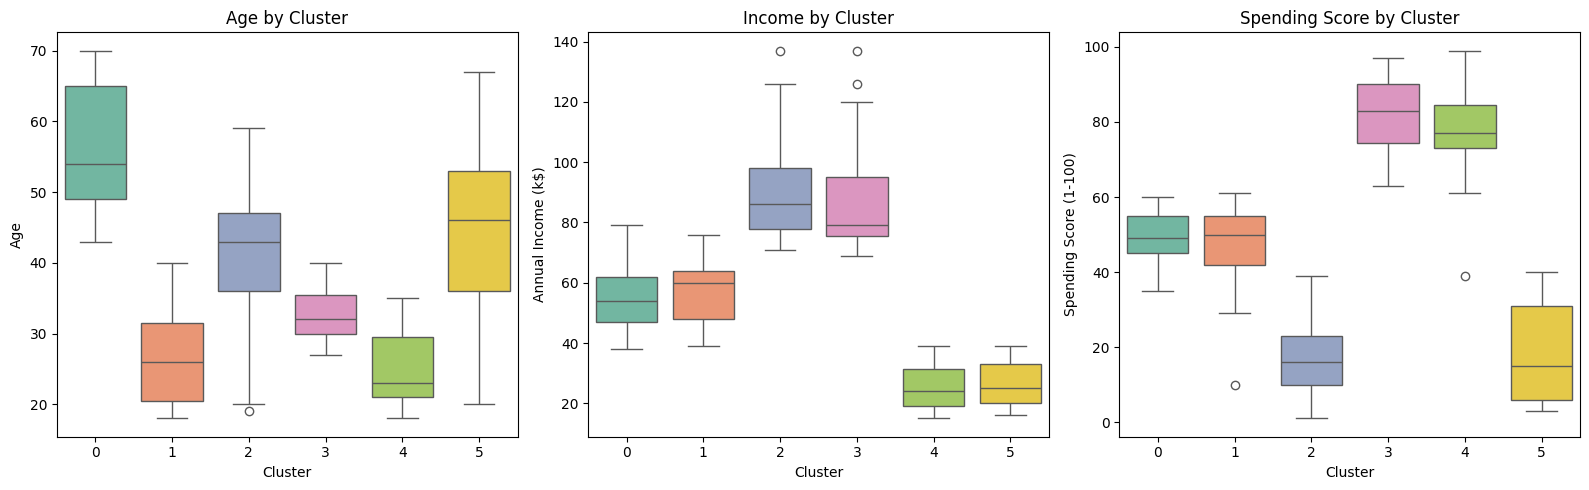

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.boxplot(data=df, x="Cluster", y="Age", ax=axes[0], palette="Set2")
axes[0].set_title("Age by Cluster")

sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", ax=axes[1], palette="Set2")
axes[1].set_title("Income by Cluster")

sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", ax=axes[2], palette="Set2")
axes[2].set_title("Spending Score by Cluster")

plt.tight_layout()
plt.show()

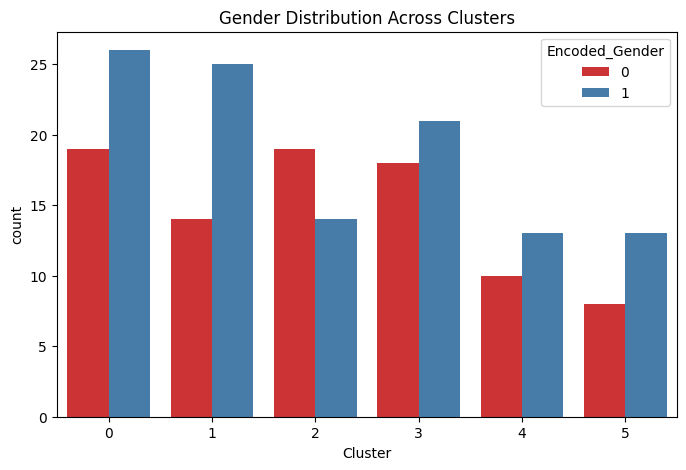

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Cluster", hue="Encoded_Gender", palette="Set1")

plt.title("Gender Distribution Across Clusters")
plt.show()

C:\Users\03cri\AppData\Local\Temp\ipykernel_36080\1921727027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


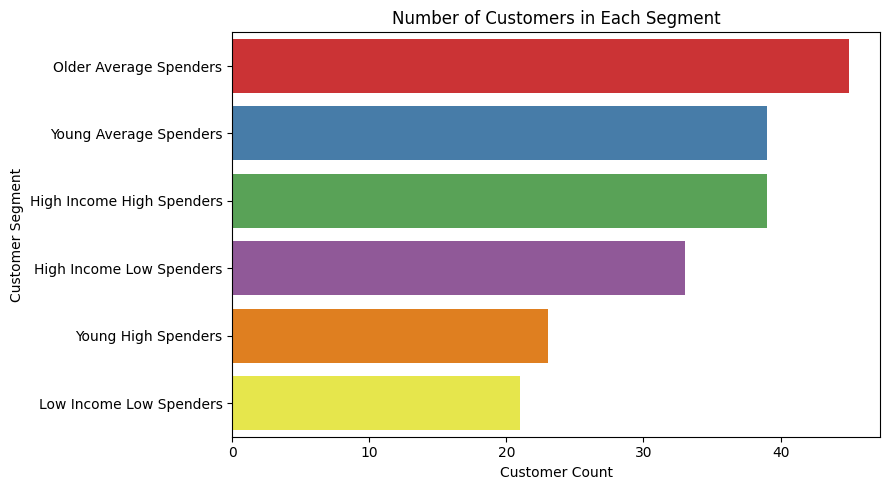

In [62]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    y="Segment",
    order=df["Segment"].value_counts().index,
    palette="Set1"
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Count")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [65]:
import joblib

df.to_csv("Mall_Customers_Clustered.csv", index=False) #save dataset with cluster labels

joblib.dump(final_kmeans, "KMeans_Model.pkl") #save KMeans model
joblib.dump(scaler, "StandardScaler.pkl") #save StandardScaler

print("Successfully saved all files.")

Successfully saved all files.
